## Correlation distance clustering

In [ ]:
import numpy as np

DATA_PATH = "student_mental_health_burnout_1M.csv"

# loading dataset
import pandas as pd
df_1m = pd.read_csv(DATA_PATH)

# extract numerical features
from pandas.api.types import is_numeric_dtype
numeric_cols = [col for col in df_1m.columns if is_numeric_dtype(df_1m[col])]
num_df_1m = df_1m[numeric_cols].copy()

num_df_1m.iloc[1:100]

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
1,20,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,0.000000
2,29,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,0.696941
3,27,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,5.380592
4,24,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,0.000000
5,29,3,7.697210,8.460408,68.332246,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,3.869208,3.918780,2.872448,10.000000,1.472916,6.603990,2.731063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,29,3,5.375062,5.338316,80.982024,5.759744,4.271680,3.533563,7.312874,2.980812,3.908400,7.057710,8.622998,9.713833,5.988744,2.950994,5.354529,4.174980
96,18,3,7.958061,9.502525,75.987530,6.433656,3.728825,1.373351,8.517508,2.637354,6.348850,5.133156,4.177367,5.851558,8.886635,2.670052,5.895885,3.365640
97,21,4,8.706658,7.597969,77.639096,7.092993,5.946303,3.397777,5.425566,2.366063,4.963052,4.937139,6.214089,5.486136,8.515191,3.597517,4.359579,1.732625
98,24,4,6.371529,5.788810,71.993119,4.895763,4.286411,1.329208,4.521030,3.077423,6.007947,4.227321,4.804397,3.157183,9.168905,2.384478,6.357009,0.020018


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# standardize data
preproc_cluster = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# limit the dataframe size to make the computation feasible
SAMPLE_SIZE = 10_000
idx = np.random.default_rng(1234).choice(len(num_df_1m), size=SAMPLE_SIZE, replace=False)
num_df_reduced = num_df_1m.iloc[idx].copy()

std_num_df = pd.DataFrame(preproc_cluster.fit_transform(num_df_reduced), columns=num_df_reduced.columns)

# get the correlation distance
from scipy.spatial.distance import pdist, squareform
corr_dist_mat = squareform(pdist(std_num_df, metric="correlation"))

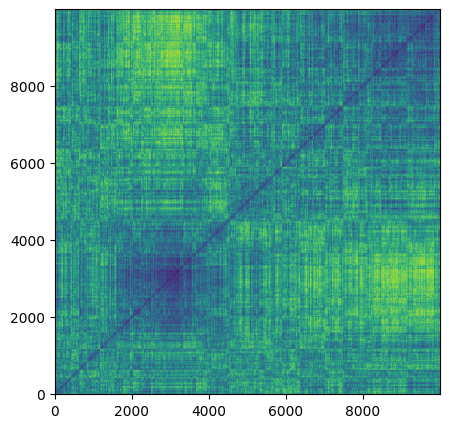

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# order datapoints based on their correlation distance
order = leaves_list(linkage(squareform(corr_dist_mat, checks=False), method="average"))
ordered = corr_dist_mat[np.ix_(order, order)]

fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.imshow(ordered, aspect="equal", origin="lower")
plt.title("Correlation distance matrix")
plt.show()

## DBSCAN

In [ ]:
MIN_NEIGHBORS_TO_TEST  = 30
min_neigh_range = [i for i in range(2,MIN_NEIGHBORS_TO_TEST+1)]

from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

# dicts for later plotting
k_dists = dict()   
knee_points = dict()
eps_vals = dict()
corr_dist_mat = squareform(pdist(std_num_df, metric="correlation"))

def get_best_eps(min_neigh :int, corr_mat) ->float:
    """
    Automatically find the best eps values (knee of the k-distance plot) for min_neigh value
    """
    # 1st: compute the k-distance
    nbrs = NearestNeighbors(n_neighbors=min_neigh, metric="precomputed")
    nbrs.fit(corr_mat)
    dist, _ = nbrs.kneighbors(corr_mat)   
    k_dist = np.sort(dist[:,-1])

    k_dists[min_neigh] = k_dist # store for plotting
    # 2nd: highlight the knee
    kneedle = KneeLocator(range(len(k_dist)), k_dist, 
                      curve='convex', direction='increasing')
    knee_points[min_neigh] = kneedle.knee
    return float(k_dist[kneedle.knee])

from sklearn.cluster import DBSCAN
print("----- starting DBSCAN trend clustering -----")
clusterings_labels = dict()
for min_neigh in min_neigh_range:
    print(f">> computing DBSCAN on min_samples={min_neigh}")
    eps = get_best_eps(min_neigh, corr_dist_mat)
    eps_vals[min_neigh] = eps   # store for plotting
    print(f"   eps value found {eps}")
    dbscan = DBSCAN(eps=eps, min_samples=min_neigh, metric="precomputed")
    clusterings_labels[min_neigh] = dbscan.fit_predict(corr_dist_mat)

----- starting DBSCAN trend clustering -----
>> computing DBSCAN on min_samples=2
   eps value found 0.263025529556395
>> computing DBSCAN on min_samples=3
   eps value found 0.305224019792107
>> computing DBSCAN on min_samples=4
   eps value found 0.3020141359571129
>> computing DBSCAN on min_samples=5
   eps value found 0.2950256807316497
>> computing DBSCAN on min_samples=6
   eps value found 0.3242196549038785
>> computing DBSCAN on min_samples=7
   eps value found 0.3074745232853425
>> computing DBSCAN on min_samples=8
   eps value found 0.33452983667459135
>> computing DBSCAN on min_samples=9
   eps value found 0.3449991579569005
>> computing DBSCAN on min_samples=10
   eps value found 0.3388330404883745
>> computing DBSCAN on min_samples=11
   eps value found 0.3397589140497703
>> computing DBSCAN on min_samples=12
   eps value found 0.36133952595443597
>> computing DBSCAN on min_samples=13
   eps value found 0.3435244434121997
>> computing DBSCAN on min_samples=14
   eps value 

In [5]:
for min_neigh in min_neigh_range:
    print(f"Cluster identified with min_pts={min_neigh}-eps={eps_vals[min_neigh]:.4f} : \
          {len(set(clusterings_labels[min_neigh])) - (1 if -1 in clusterings_labels[min_neigh] else 0)}")

Cluster identified with min_pts=2-eps=0.2630 :           4
Cluster identified with min_pts=3-eps=0.3052 :           1
Cluster identified with min_pts=4-eps=0.3020 :           1
Cluster identified with min_pts=5-eps=0.2950 :           1
Cluster identified with min_pts=6-eps=0.3242 :           1
Cluster identified with min_pts=7-eps=0.3075 :           1
Cluster identified with min_pts=8-eps=0.3345 :           1
Cluster identified with min_pts=9-eps=0.3450 :           1
Cluster identified with min_pts=10-eps=0.3388 :           1
Cluster identified with min_pts=11-eps=0.3398 :           1
Cluster identified with min_pts=12-eps=0.3613 :           1
Cluster identified with min_pts=13-eps=0.3435 :           1
Cluster identified with min_pts=14-eps=0.3476 :           1
Cluster identified with min_pts=15-eps=0.3619 :           1
Cluster identified with min_pts=16-eps=0.3684 :           1
Cluster identified with min_pts=17-eps=0.3688 :           1
Cluster identified with min_pts=18-eps=0.3711 : 

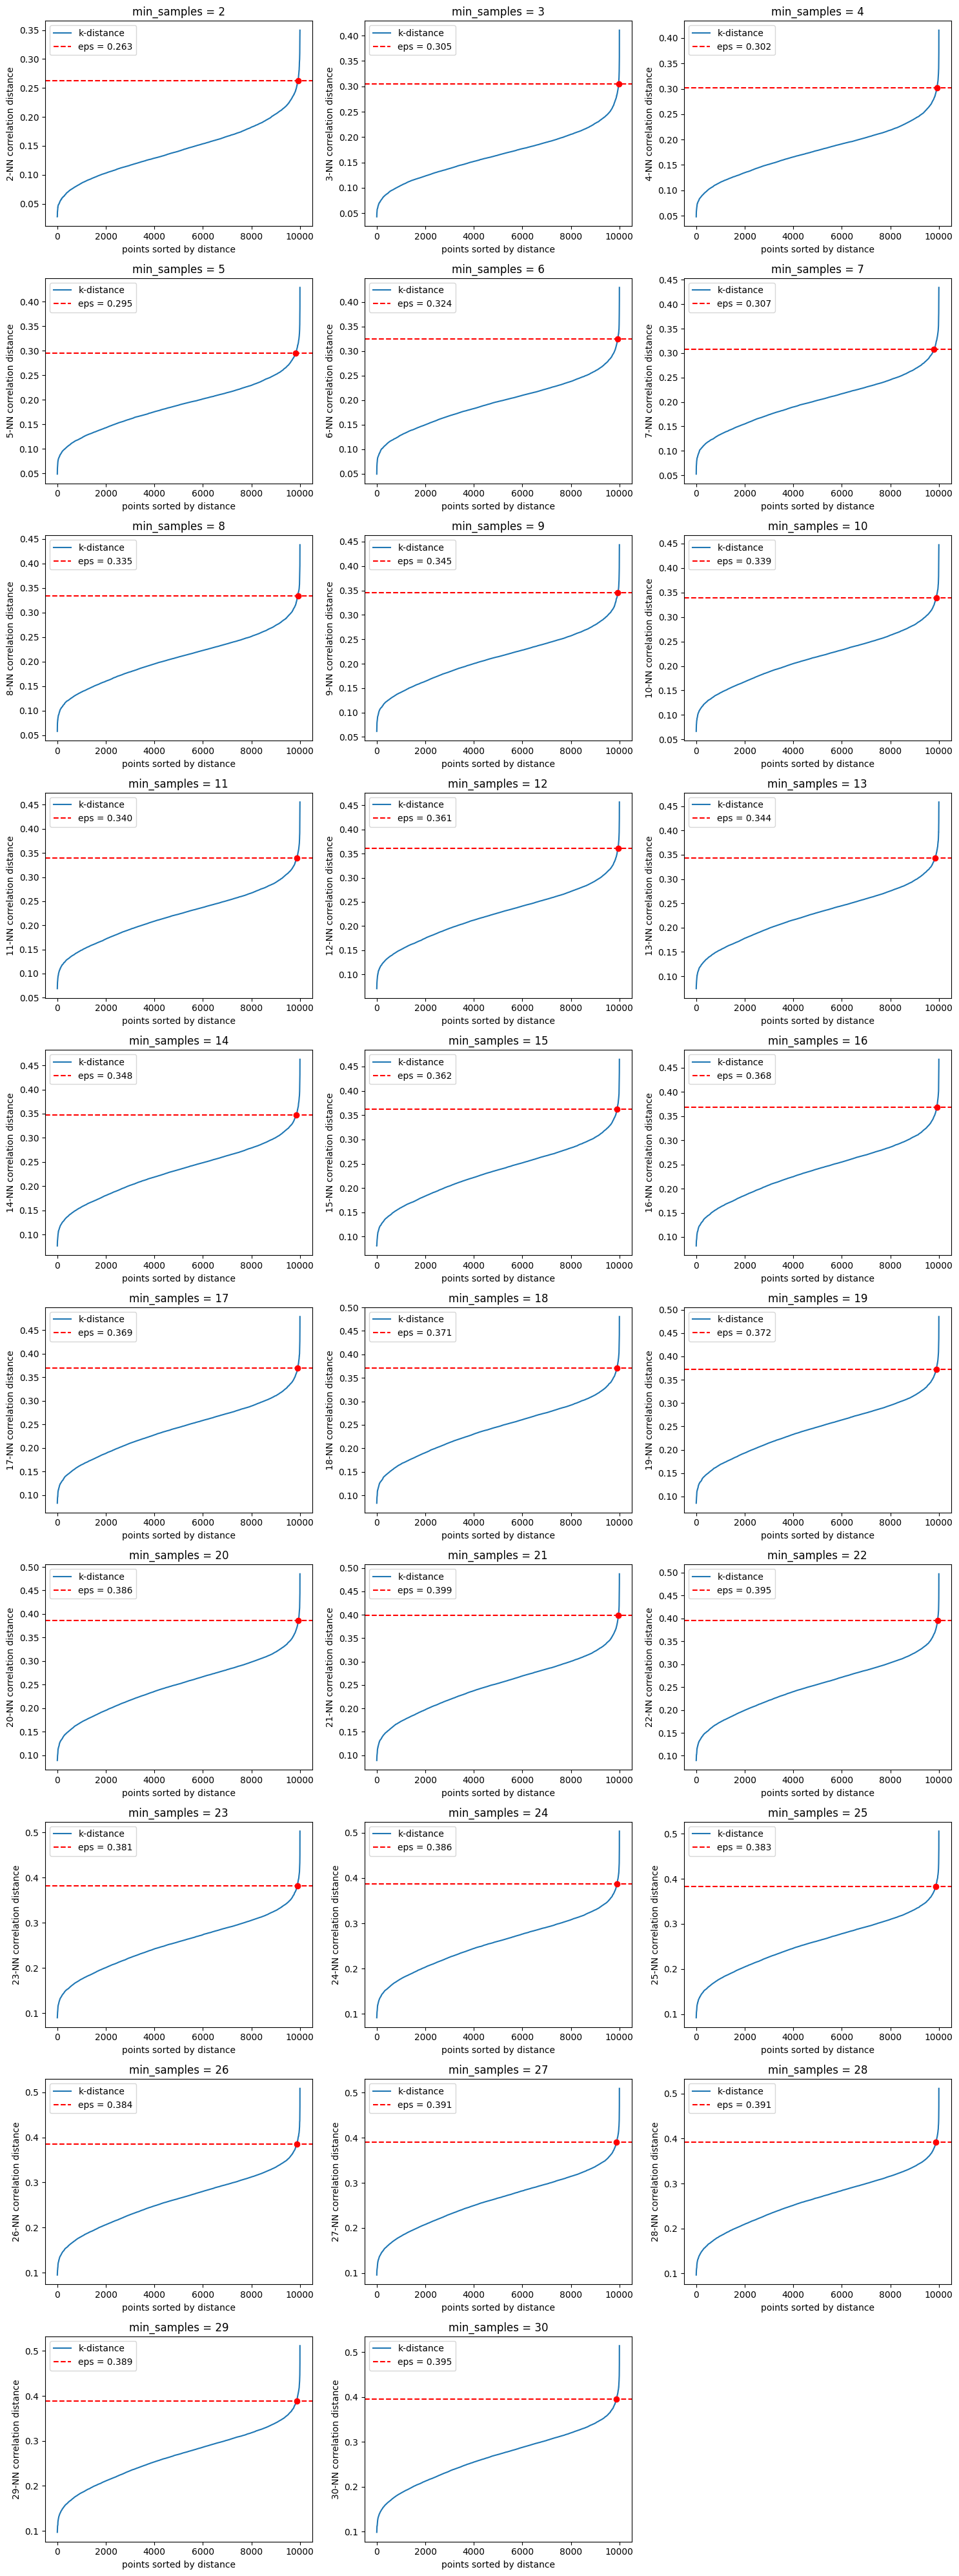

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(min_neigh_range) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, min_neigh in zip(axes, min_neigh_range):
    k_dist = k_dists[min_neigh]
    knee = knee_points[min_neigh]
    eps = eps_vals[min_neigh]

    ax.plot(k_dist, label="k-distance")
    ax.axhline(eps, color="r", linestyle="--", label=f"eps = {eps:.3f}")
    ax.scatter([knee], [eps], color="r", zorder=5)
    ax.set_title(f"min_samples = {min_neigh}")
    ax.set_xlabel("points sorted by distance")
    ax.set_ylabel(f"{min_neigh}-NN correlation distance")
    ax.legend()

for ax in axes[len(min_neigh_range):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Spectral Clustering

In [ ]:
from sklearn.cluster import SpectralClustering


# Spectral Clustering (SC) works using eigenvalues of the Laplacian matrix of the data.
# More info: https://grahamjroy.medium.com/spectral-clustering-when-clusters-dont-look-like-blobs-a205e1fc8d0e

# 1st: SC evaluates the point clusters using the similarity between them
sigma = np.median(corr_dist_mat)  # sigma controls how sharply similarity decays with distance
affinity = np.exp(-corr_dist_mat**2 / (2 * sigma**2))

# 2nd: run spectral clustering
sc = SpectralClustering(
    n_clusters=2,
    affinity="precomputed", 
    assign_labels="kmeans",   # or "discretize", try it ot
    random_state=42,
    n_init=10                 # run kmeans multiple times for stability
)
labels = sc.fit_predict(affinity)

print(np.unique(labels, return_counts=True))

(array([0, 1], dtype=int32), array([4580, 5420]))


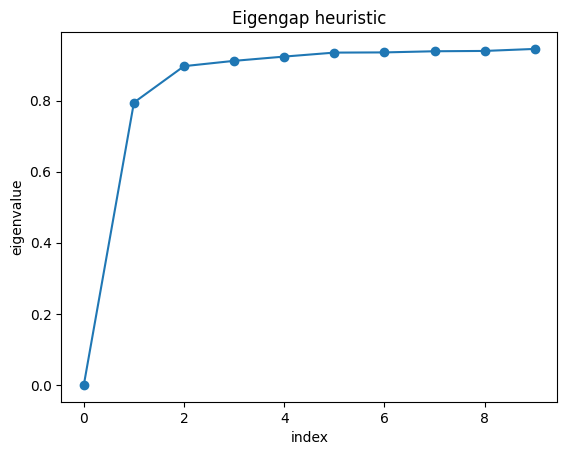

In [ ]:
from scipy.sparse.csgraph import laplacian

L = laplacian(affinity, normed=True)
eigenvalues = np.linalg.eigvalsh(L)

import matplotlib.pyplot as plt
plt.plot(eigenvalues[:10], 'o-')
plt.xlabel("index")
plt.ylabel("eigenvalue")
plt.title("Eigengap heuristic")
plt.show()